# Sector Analysis

**EDA: Sector Analysis**

This notebook explores how companies currently loaded into the SmartStock
data warehouse compare across sectors: company counts and fundamentals by
sector, average performance/volatility by sector, and a cross-sector
comparison.

In [1]:

import sys
import warnings
from pathlib import Path

project_root = Path.cwd().resolve()
while not (project_root / "src").exists() and project_root != project_root.parent:
    project_root = project_root.parent
sys.path.insert(0, str(project_root))

import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore", message=".*only supports SQLAlchemy.*")

from src.utils.database import get_connection

pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
plt.rcParams["figure.figsize"] = (12, 5)

## 1. Load Data

In [2]:
with get_connection() as conn:
    companies_df = pd.read_sql(
        """
        SELECT company_id, symbol, company_name, sector, industry, market_cap, pe_ratio, eps
        FROM companies
        ORDER BY sector, symbol;
        """,
        conn,
    )
    prices_df = pd.read_sql(
        """
        SELECT hp.company_id, c.symbol, c.sector, hp.date, hp.open, hp.high, hp.low, hp.close, hp.volume
        FROM historical_prices hp
        JOIN companies c ON c.company_id = hp.company_id
        ORDER BY c.symbol, hp.date;
        """,
        conn,
    )

prices_df["date"] = pd.to_datetime(prices_df["date"])
print(f"Loaded {len(companies_df)} companies across {companies_df['sector'].nunique()} sector(s) and {len(prices_df)} price rows.")
companies_df

Loaded 5 companies across 4 sector(s) and 1825 price rows.


,company_id,symbol,company_name,sector,industry,market_cap,pe_ratio,eps
0,7,JPM,JPMorgan Chase & Co,Banking,Banking,"881,693.24",15.46,20.51
1,8,XOM,Exxon Mobil Corp,Energy,Energy,"588,002.20",19.62,6.70
2,3,GOOGL,Alphabet Inc,Media,Media,"4,107,574.80",31.08,10.81
3,1,AAPL,Apple Inc,Technology,Technology,"4,167,977.92",37.21,7.46
4,2,MSFT,Microsoft Corp,Technology,Technology,"2,770,583.14",27.21,13.64


## 2. Company Count and Fundamentals by Sector

How many tracked companies fall into each sector, and the average
market cap / P/E ratio / EPS within each sector.

In [3]:
if companies_df.empty:
    print("No company data found. Run the ingestion + ETL pipeline first (see the prerequisite note above).")
else:
    sector_fundamentals = (
        companies_df.groupby("sector")
        .agg(
            company_count=("symbol", "count"),
            avg_market_cap=("market_cap", "mean"),
            avg_pe_ratio=("pe_ratio", "mean"),
            avg_eps=("eps", "mean"),
        )
        .sort_values("company_count", ascending=False)
    )
    sector_fundamentals

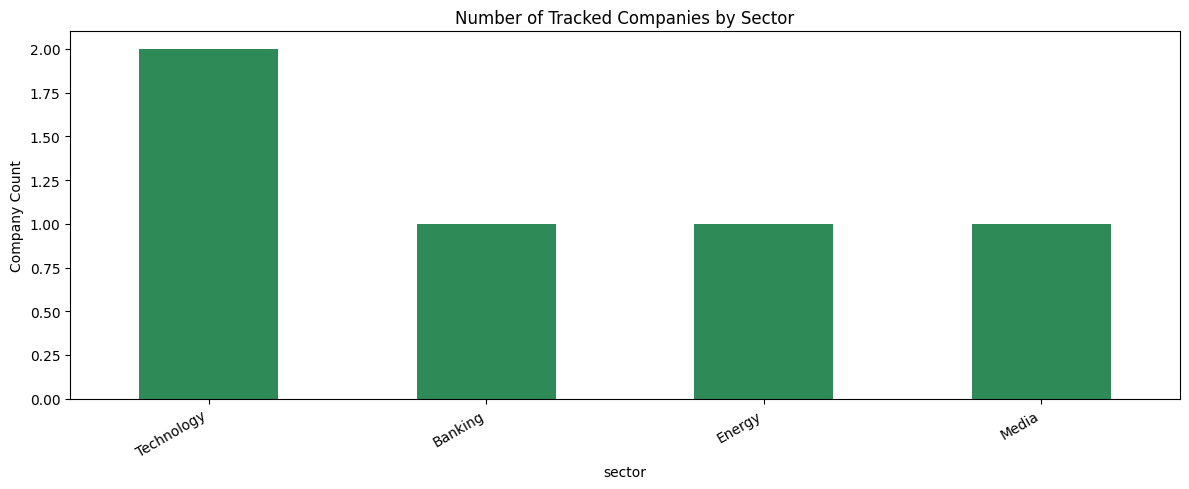

In [4]:
if not companies_df.empty:
    fig, ax = plt.subplots()
    sector_fundamentals["company_count"].plot(kind="bar", ax=ax, color="seagreen")
    ax.set_title("Number of Tracked Companies by Sector")
    ax.set_ylabel("Company Count")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.show()

## 3. Average Return by Sector

Cumulative return per symbol over the loaded date range, averaged within
each sector — a rough read on which sectors have outperformed others in
the available data.

In [5]:
if not prices_df.empty:
    cumulative_by_symbol = (
        prices_df.sort_values(["symbol", "date"])
        .groupby(["symbol", "sector"])
        .apply(lambda g: (g["close"].iloc[-1] / g["close"].iloc[0] - 1) * 100, include_groups=False)
        .rename("cumulative_return_pct")
        .reset_index()
    )

    avg_return_by_sector = (
        cumulative_by_symbol.groupby("sector")["cumulative_return_pct"]
        .mean()
        .sort_values(ascending=False)
    )
    avg_return_by_sector

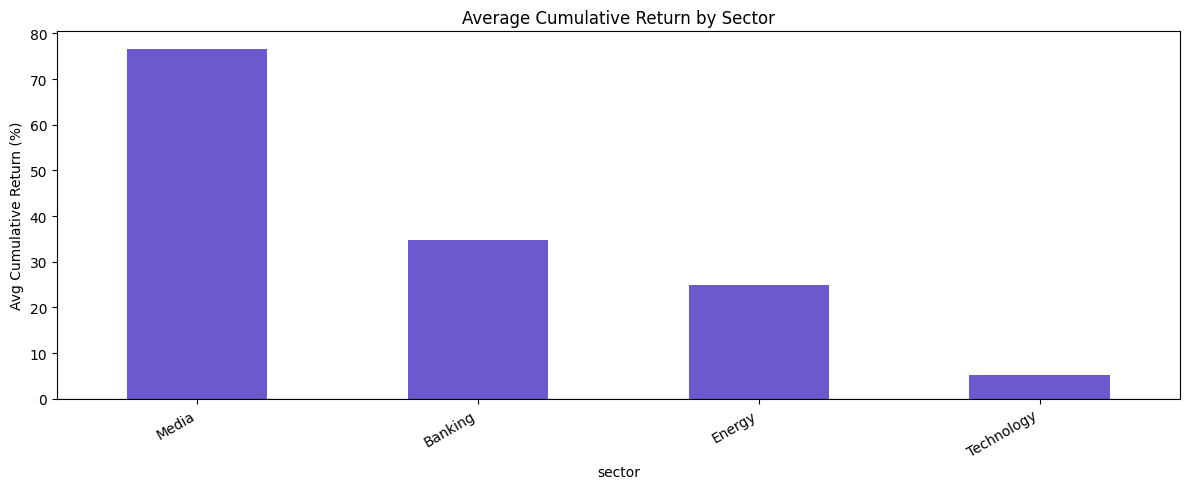

In [6]:
if not prices_df.empty:
    fig, ax = plt.subplots()
    avg_return_by_sector.plot(kind="bar", ax=ax, color="slateblue")
    ax.set_title("Average Cumulative Return by Sector")
    ax.set_ylabel("Avg Cumulative Return (%)")
    ax.axhline(0, color="black", linewidth=0.8)
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.show()

## 4. Average Volatility by Sector

Average daily-return volatility per symbol, grouped by sector — combines
the per-symbol volatility metric from `volatility_analysis.ipynb` with a
sector-level rollup.

In [7]:
if not prices_df.empty:
    returns_df = prices_df.sort_values(["symbol", "date"]).copy()
    returns_df["daily_return_pct"] = returns_df.groupby("symbol")["close"].pct_change() * 100

    volatility_by_symbol = (
        returns_df.groupby(["symbol", "sector"])["daily_return_pct"]
        .std()
        .rename("volatility_pct")
        .reset_index()
    )

    avg_volatility_by_sector = (
        volatility_by_symbol.groupby("sector")["volatility_pct"]
        .mean()
        .sort_values(ascending=False)
    )
    avg_volatility_by_sector

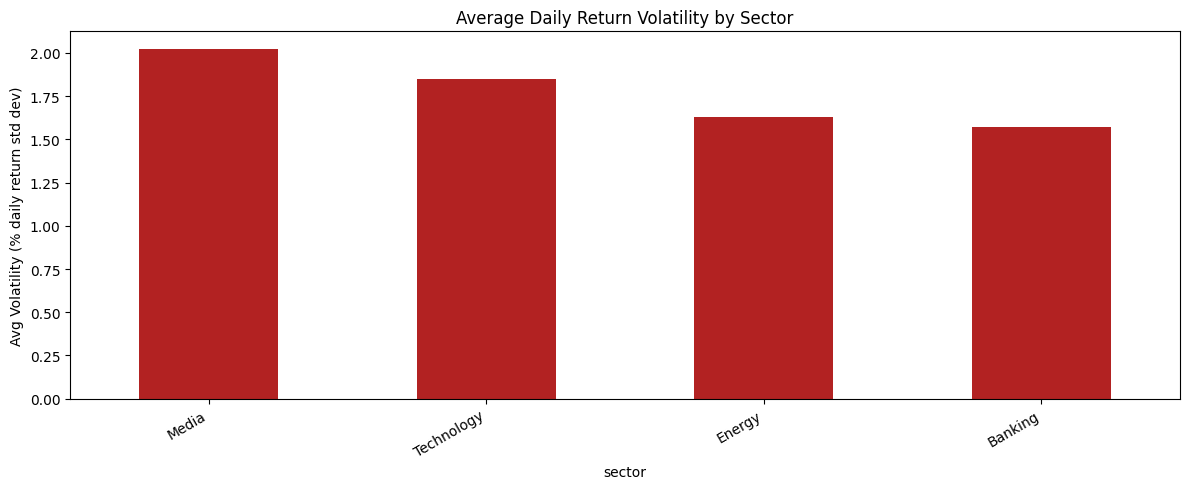

In [8]:
if not prices_df.empty:
    fig, ax = plt.subplots()
    avg_volatility_by_sector.plot(kind="bar", ax=ax, color="firebrick")
    ax.set_title("Average Daily Return Volatility by Sector")
    ax.set_ylabel("Avg Volatility (% daily return std dev)")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.show()

## 5. Risk vs. Return by Sector

A scatter plot combining sections 3 and 4: sectors in the upper-left
(high return, low volatility) are the most attractive on a simple
risk-adjusted basis; sectors in the lower-right are the least attractive.

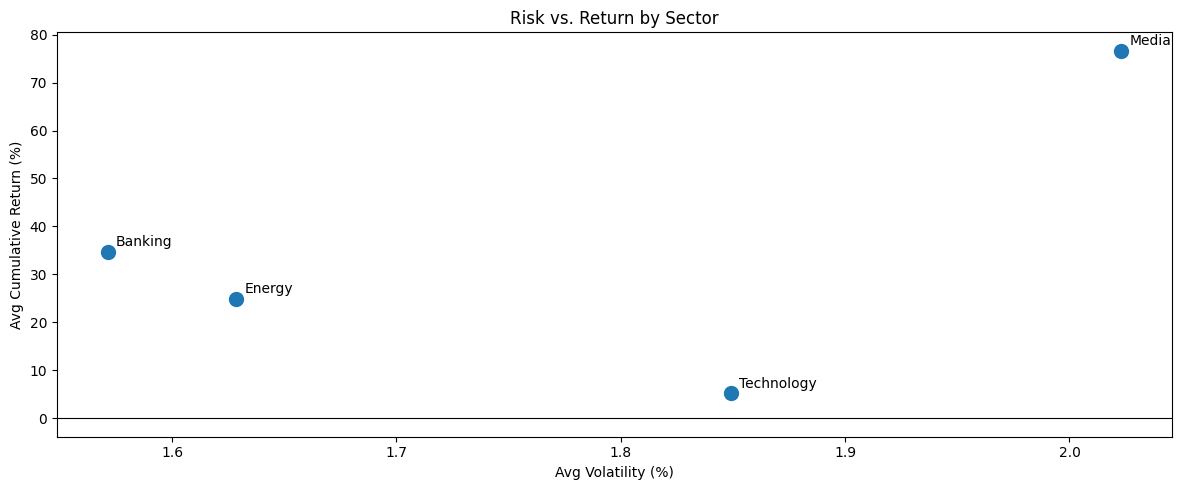

In [9]:
if not prices_df.empty:
    risk_return_df = avg_return_by_sector.to_frame().join(avg_volatility_by_sector)

    fig, ax = plt.subplots()
    ax.scatter(risk_return_df["volatility_pct"], risk_return_df["cumulative_return_pct"], s=100)
    for sector, row in risk_return_df.iterrows():
        ax.annotate(sector, (row["volatility_pct"], row["cumulative_return_pct"]),
                    textcoords="offset points", xytext=(6, 4))
    ax.set_xlabel("Avg Volatility (%)")
    ax.set_ylabel("Avg Cumulative Return (%)")
    ax.set_title("Risk vs. Return by Sector")
    ax.axhline(0, color="black", linewidth=0.8)
    plt.tight_layout()
    plt.show()

## 7. Cross-Symbol Return Correlation

A correlation heatmap of daily returns across all loaded symbols.

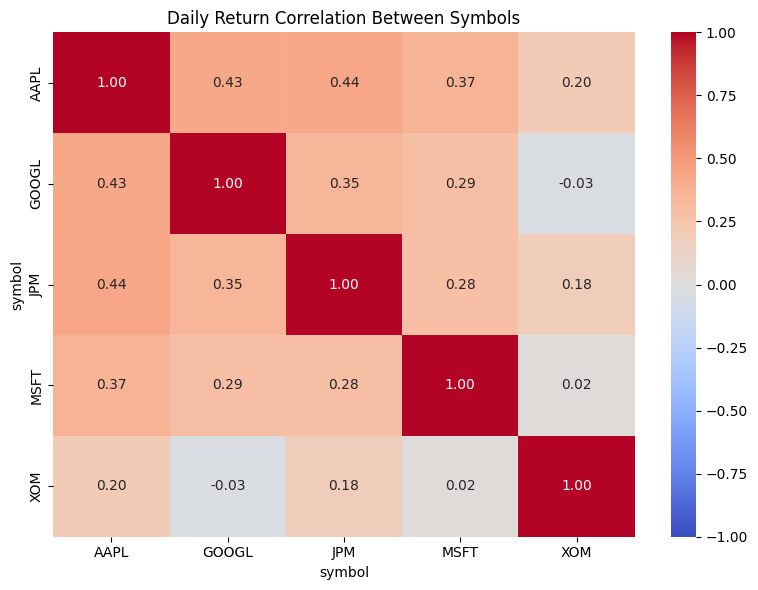

In [10]:
if not prices_df.empty:
    import seaborn as sns

    returns_pivot = (
        returns_df.pivot(index="date", columns="symbol", values="daily_return_pct")
    )
    correlation_matrix = returns_pivot.corr()

    fig, ax = plt.subplots(figsize=(8, 6))
    sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, ax=ax)
    ax.set_title("Daily Return Correlation Between Symbols")
    plt.tight_layout()
    plt.show()